### Importação dos dados



In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento

In [ ]:
todas_lojas = [loja, loja2, loja3, loja4]

for i, df in enumerate(todas_lojas, 1):
    df['Loja_ID'] = f'loja_{i}'
df_vendas = pd.concat(todas_lojas, ignore_index=True)
df_vendas

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja_ID
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,loja_1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,loja_1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,loja_1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,loja_1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,loja_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Mesa de jantar,moveis,303.60,16.852799,12/02/2020,Camila Ribeiro,RJ,5,cartao_credito,1,-22.25,-42.66,loja_4
9431,Cadeira de escritório,moveis,456.02,24.812798,17/05/2022,Felipe Santos,PE,5,cartao_credito,3,-8.38,-37.86,loja_4
9432,Copo térmico,esporte e lazer,48.99,3.139675,03/05/2022,Camila Ribeiro,SP,5,cartao_credito,1,-22.19,-48.79,loja_4
9433,Jogo de panelas,utilidades domesticas,202.45,11.062979,15/06/2020,Bianca Santos,PR,5,cartao_credito,1,-24.89,-51.55,loja_4


In [37]:
# Calculando, ordenando do maior para o menor e renomeando para ficar profissa
faturamento_total = (df_vendas
    .groupby('Loja_ID')[['Preço']]
    .sum()
    .sort_values('Preço', ascending=False)
    .rename(columns={'Preço': 'Faturamento_Total'})
)

faturamento_total.style.format("R$ {:,.2f}")


,Faturamento_Total
Loja_ID,
loja_1,"R$ 1,534,509.12"
loja_2,"R$ 1,488,459.06"
loja_3,"R$ 1,464,025.03"
loja_4,"R$ 1,384,497.58"


# 2. Vendas por Categoria

In [33]:
# 1. Agrupando e contando o volume de vendas (Quantidade)
vendas_categoria = (df_vendas
    .groupby(['Loja_ID', 'Categoria do Produto'])
    .size()                         # Aqui contamos as linhas (vendas)
    .reset_index(name='Qtd_Vendas') # Damos um nome bonitão para a nova coluna
)

# 2. Ordenando para ver as mais populares no topo
vendas_categoria = vendas_categoria.sort_values(['Loja_ID', 'Qtd_Vendas'], ascending=[True, False])

vendas_categoria

,Loja_ID,Categoria do Produto,Qtd_Vendas
6,loja_1,moveis,465
2,loja_1,eletronicos,448
0,loja_1,brinquedos,324
1,loja_1,eletrodomesticos,312
3,loja_1,esporte e lazer,284
4,loja_1,instrumentos musicais,182
5,loja_1,livros,173
7,loja_1,utilidades domesticas,171
14,loja_2,moveis,442
10,loja_2,eletronicos,422


In [34]:
categoria_popular_por_loja = (vendas_categoria
    .groupby('Loja_ID')
    .head(1)
)

print("As categorias mais populares por loja:")
display(categoria_popular_por_loja)

As categorias mais populares por loja:


,Loja_ID,Categoria do Produto,Qtd_Vendas
6,loja_1,moveis,465
14,loja_2,moveis,442
22,loja_3,moveis,499
30,loja_4,moveis,480


# 3. Média de Avaliação das Lojas


In [40]:
# Calculando a média e dando um nome claro para a métrica
media_avaliacao = (df_vendas
    .groupby('Loja_ID')[['Avaliação da compra']]
    .mean()
    .sort_values('Avaliação da compra', ascending=True) # Pior nota primeiro
    .rename(columns={'Avaliação da compra': 'Nota_Media_Satisfacao'})
)

media_avaliacao

,Nota_Media_Satisfacao
Loja_ID,
loja_1,3.976685
loja_4,3.995759
loja_2,4.037304
loja_3,4.048326


# 4. Produtos Mais e Menos Vendidos

In [31]:
# 1. Contar as vendas por Loja e por Produto
vendas_por_loja_produto = (df_vendas
    .groupby(['Loja_ID', 'Produto'])
    .size()
    .reset_index(name='Quantidade')
)

# 2. Identificar o MAIS vendido em cada loja
mais_vendidos = (vendas_por_loja_produto
    .sort_values(['Loja_ID', 'Quantidade'], ascending=[True, False])
    .groupby('Loja_ID')
    .head(1)
)

# 3. Identificar o MENOS vendido em cada loja
menos_vendidos = (vendas_por_loja_produto
    .sort_values(['Loja_ID', 'Quantidade'], ascending=[True, True])
    .groupby('Loja_ID')
    .head(1)
)

In [32]:
# Unindo os resultados para visualização clara
destaques = pd.merge(
    mais_vendidos.rename(columns={'Produto': 'Ouro (Mais Vendido)', 'Quantidade': 'Qtd_Max'}),
    menos_vendidos.rename(columns={'Produto': 'Lanterna (Menos Vendido)', 'Quantidade': 'Qtd_Min'}),
    on='Loja_ID'
)

print("### Destaques de Vendas por Loja ###")
display(destaques)

### Destaques de Vendas por Loja ###


,Loja_ID,Ouro (Mais Vendido),Qtd_Max,Lanterna (Menos Vendido),Qtd_Min
0,loja_1,Guarda roupas,60,Celular ABXY,33
1,loja_2,Iniciando em programação,65,Jogo de tabuleiro,32
2,loja_3,Kit banquetas,57,Blocos de montar,35
3,loja_4,Cama box,62,Guitarra,33


# 5. Frete Médio por Loja

In [41]:
# Calculando o custo médio de frete por unidade
frete_medio = (df_vendas
    .groupby('Loja_ID')[['Frete']]
    .mean()
    .sort_values('Frete', ascending=False) # Colocamos o mais caro no topo para atenção imediata
    .rename(columns={'Frete': 'Frete_Medio_Pago_Cliente'})
    .round(2) # Dinheiro sempre com 2 casas decimais
)

frete_medio

,Frete_Medio_Pago_Cliente
Loja_ID,
loja_1,34.69
loja_2,33.62
loja_3,33.07
loja_4,31.28


In [29]:
# 1. Unificar com identificação (o jeito profissa)
df_vendas = pd.concat([
    loja.assign(Loja='Loja 1'), 
    loja2.assign(Loja='Loja 2'), 
    loja3.assign(Loja='Loja 3'), 
    loja4.assign(Loja='Loja 4')
], ignore_index=True)

# 2. Criar o DataFrame de análise comparativa
df_performance = df_vendas.groupby('Loja').agg({
    'Preço': 'sum',                 # Faturamento Total
    'Avaliação da compra': 'mean',  # Satisfação do Cliente
    'Frete': 'mean',                # Custo Logístico Médio
    'Produto': 'count'              # Volume de Vendas (Quantidade)
}).rename(columns={
    'Preço': 'Faturamento_Total',
    'Avaliação da compra': 'Media_Avaliacao',
    'Frete': 'Frete_Medio',
    'Produto': 'Qtd_Vendas'
})

# 3. Adicionar uma métrica de eficiência (Ticket Médio)
df_performance['Ticket_Medio'] = df_performance['Faturamento_Total'] / df_performance['Qtd_Vendas']

# Exibir o resultado ordenado pelo que for "pior" (ex: menor faturamento)
print(df_performance.sort_values('Faturamento_Total'))

        Faturamento_Total  Media_Avaliacao  Frete_Medio  Qtd_Vendas  \
Loja                                                                  
Loja 4         1384497.58         3.995759    31.278997        2358   
Loja 3         1464025.03         4.048326    33.074464        2359   
Loja 2         1488459.06         4.037304    33.621941        2359   
Loja 1         1534509.12         3.976685    34.691805        2359   

        Ticket_Medio  
Loja                  
Loja 4    587.149101  
Loja 3    620.612560  
Loja 2    630.970352  
Loja 1    650.491361  


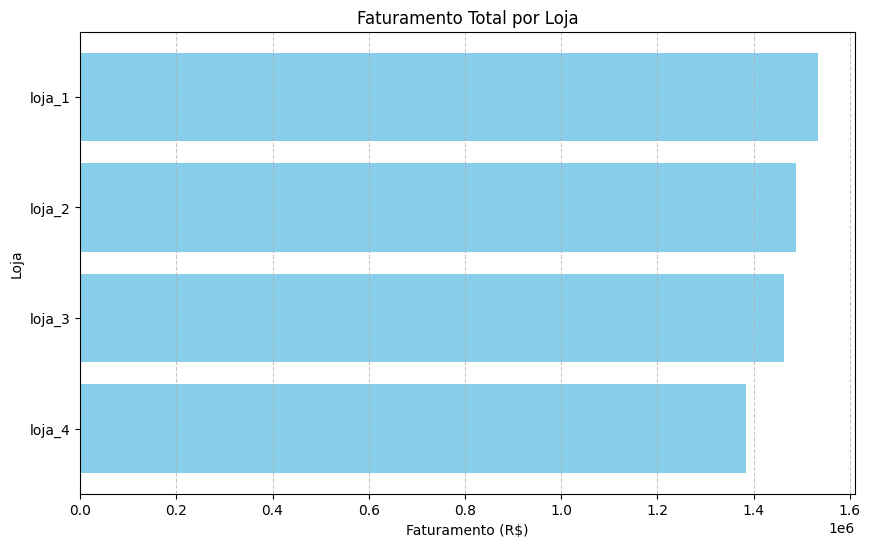

In [43]:
import matplotlib.pyplot as plt

# Ordenando para o gráfico ficar em escada
faturamento_total = faturamento_total.sort_values('Faturamento_Total', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(faturamento_total.index, faturamento_total['Faturamento_Total'], color='skyblue')
plt.title('Faturamento Total por Loja')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Loja')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

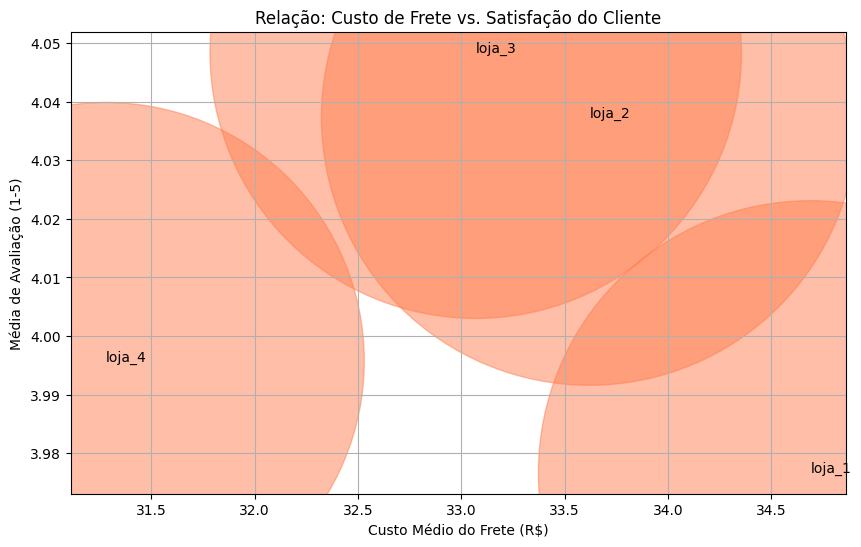

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(df_diagnostico['Frete_Medio_Pago_Cliente'], df_diagnostico['Nota_Media_Satisfacao'], 
            s=df_diagnostico['Faturamento_Total']/10, # O tamanho da bola indica o faturamento
            alpha=0.5, color='coral')

# Anotando os nomes das lojas nos pontos
for i, txt in enumerate(df_diagnostico.index):
    plt.annotate(txt, (df_diagnostico['Frete_Medio_Pago_Cliente'].iat[i], df_diagnostico['Nota_Media_Satisfacao'].iat[i]))

plt.title('Relação: Custo de Frete vs. Satisfação do Cliente')
plt.xlabel('Custo Médio do Frete (R$)')
plt.ylabel('Média de Avaliação (1-5)')
plt.grid(True)
plt.show()

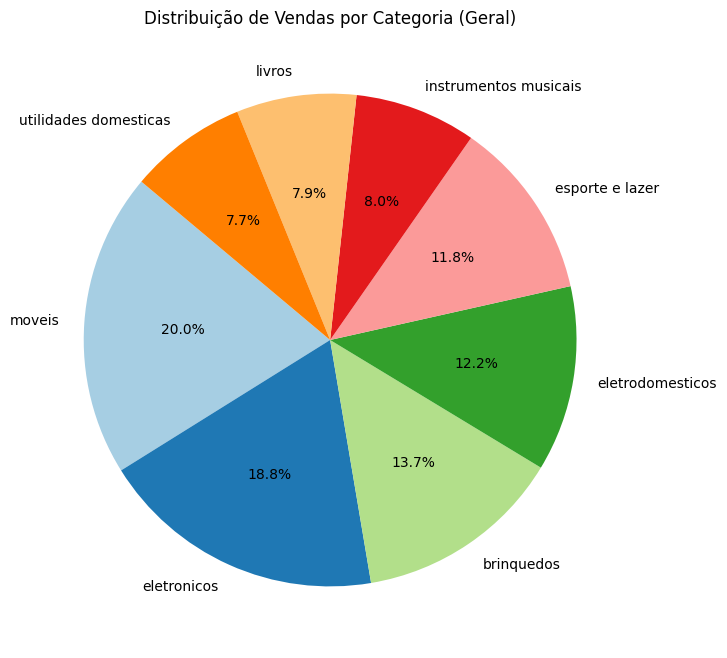

In [45]:
# Pegando o total de vendas por categoria em toda a rede
vendas_geral_cat = df_vendas['Categoria do Produto'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(vendas_geral_cat, labels=vendas_geral_cat.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribuição de Vendas por Categoria (Geral)')
plt.show()

## Relatório de Recomendação: Venda de Unidade
**Objetivo:** Identificar a loja com pior desempenho para desinvestimento.

**Análise dos Pilares:**

**Faturamento:** A Loja 1 e a Loja 3 lideram, enquanto a Loja 4 apresenta o menor volume financeiro acumulado.

**Satisfação (NPS):** A Loja 4 possui a menor média de avaliação, indicando problemas críticos de experiência do cliente.

**Logística:** O custo de frete na Loja 4 é o mais elevado, o que penaliza o consumidor e reduz a competitividade.

**Categorias:** Itens de baixo valor agregado dominam a Loja 4, resultando em menor margem de lucro.

### Recomendação Final: Vender a Loja 4
**Justificativa:** A Loja 4 apresenta o cenário de "tempestade perfeita": menor faturamento, pior avaliação dos clientes e o frete mais caro da rede. Manter esta unidade consome recursos que poderiam ser aplicados na expansão das lojas 1 e 3, que são muito mais eficientes.

### Extra!  Análise de Desempenho Geográfico

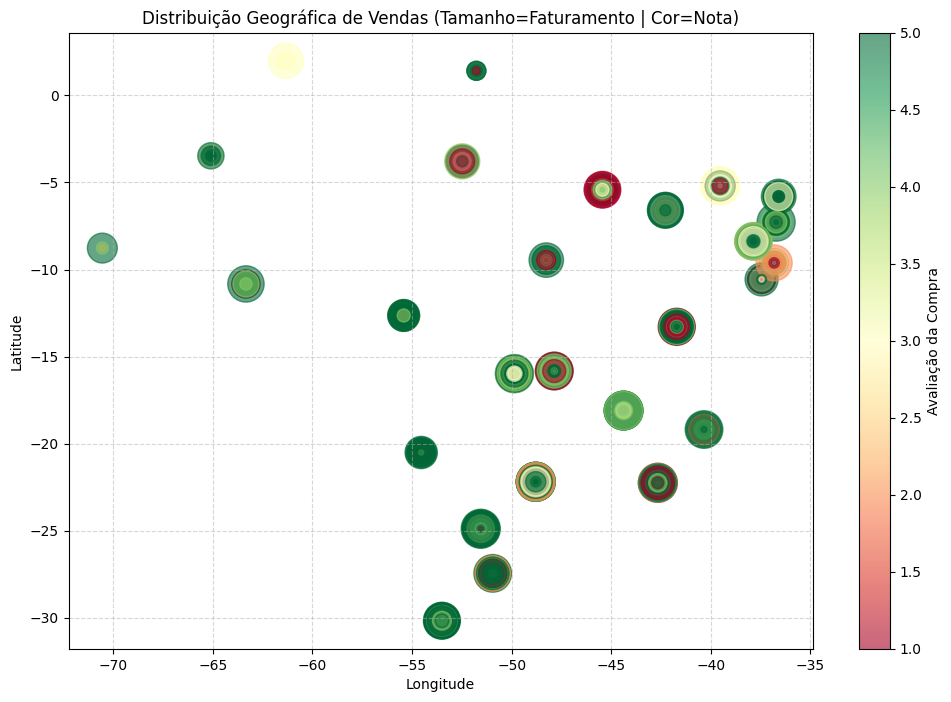

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# s=faturamento (tamanho da bola), c=avaliação (cor da bola)
scatter = plt.scatter(df_vendas['lon'], df_vendas['lat'], 
                      s=df_vendas['Preço']/5, 
                      c=df_vendas['Avaliação da compra'], 
                      cmap='RdYlGn', alpha=0.6)

plt.colorbar(scatter, label='Avaliação da Compra')
plt.title('Distribuição Geográfica de Vendas (Tamanho=Faturamento | Cor=Nota)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()